- In this notebook: Extending data set for SEA, sorting by 20-50 keV counts and taking top 200

- Extending past top 200, issues start to arise with duration function (difference btwn. data points too low for current method) and energy ranges

In [66]:
import matplotlib.pyplot as plt
import numpy as np

from astropy.visualization import time_support
from astropy.time import Time
import astropy.units as u

from sunpy import timeseries as ts
from sunpy.net import Fido
from sunpy.net import attrs as a

from stixpy.net.client import STIXClient
from stixpy.timeseries import quicklook 
from stixpy.product import Product

import datetime as dt
from sunpy.time import parse_time
from sunpy.time import TimeRange

import pandas as pd

from scipy.signal import find_peaks, savgol_filter

from matplotlib import dates

In [67]:
def t(string):
    return parse_time(string).datetime

def get_energy_indices(qtable, ranges):
    energy_indices = []
    for e_min, e_max in ranges:
        start_index = np.where(qtable["e_low"] >= e_min)[0][0]
        end_index = np.where(qtable["e_high"] <= e_max)[0][-1]
        energy_indices.append([int(start_index), int(end_index)])
    return energy_indices
    
def get_stix_df(stix_sci, energy_ranges):
    
    energy_indices = get_energy_indices(stix_sci.energies, energy_ranges)
    counts, errors, times, timedeltas, energies = stix_sci.get_data(detector_indices=[[0, 31]],
                                                                    pixel_indices=[[0, 11]],
                                                                    energy_indices=energy_indices,)
    counts = counts.to(u.ct / u.s / u.keV)
    errors = errors.to(u.ct / u.s / u.keV)
    timedeltas = timedeltas.to(u.s)
    
    times = times
    
    energy_columns = [f"{e['e_low']}-{e['e_high']}" for e in energies]
    
    counts_reshaped = counts[:, 0, 0, :]
    
    counts_df = pd.DataFrame(counts_reshaped, index=times.datetime, columns=energy_columns)
    return counts_df

def rank_overlaps(start, end, sci_query):
    overlaps=[]
    for n in range(len(sci_query[0])):
        latest_start = max(start, sci_query[0][n][0].datetime)
        earliest_end = min(end, sci_query[0][n][1].datetime)
        
        overlap = earliest_end - latest_start
        overlaps.append((overlap.total_seconds(), n))
        
    return np.array(sorted(overlaps, key=lambda x: x[0], reverse=True))

In [68]:
energy_ranges = [(25.0*u.keV, 50*u.keV), (50.0*u.keV, 100*u.keV)]

In [69]:
flares = pd.read_csv("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/data/STIX_flarelist_w_locations_20210214_20260228_version1_python.csv")
flarelist = flares.sort_values("25-50 keV", ascending=False).head(200)

In [70]:
flarelist

,start_UTC,end_UTC,peak_UTC,4-10 keV,10-15 keV,15-25 keV,25-50 keV,50-84 keV,bkg 4-10 keV,bkg 10-15 keV,...,flare_id,sidelobes_ratio,goes_estimated_min_class,goes_estimated_max_class,goes_estimated_mean_class,goes_estimated_min_flux,goes_estimated_max_flux,goes_estimated_mean_flux,error_with_imaging,cpd_filename
16121,2024-05-20T05:10:08.351,2024-05-20T06:52:32.361,2024-05-20T05:14:40.351,15995187,409599,884735,475135,204799,247.0,37.0,...,2405200514,0.750127,X6,X25,X12,5.834281e-04,0.002534,1.198135e-03,False,/Users/laurahayes/flare_analysis/new_stix_flar...
15798,2024-05-14T16:43:32.086,2024-05-14T17:02:16.088,2024-05-14T16:47:32.086,13148990,442367,753663,311295,155647,303.0,41.0,...,2405141647,0.754086,X4,X18,X8,4.217016e-04,0.001782,8.543020e-04,False,/Users/laurahayes/flare_analysis/new_stix_flar...
4360,2022-09-29T11:44:36.211,2022-09-29T12:51:48.218,2022-09-29T11:51:36.211,6411371,376831,507903,188415,77823,271.0,45.0,...,2209291151,0.798857,M7,X3,X1,7.000000e-05,0.000300,1.000000e-04,False,/Users/laurahayes/flare_analysis/new_stix_flar...
4361,2022-09-29T11:44:32.211,2022-09-29T12:51:56.218,2022-09-29T11:57:32.212,1769471,376831,507903,188415,77823,271.0,45.0,...,2209291157,0.800781,M2,M8,M4,2.000000e-05,0.000080,4.000000e-05,False,/Users/laurahayes/flare_analysis/new_stix_flar...
21278,2024-10-03T12:04:29.984,2024-10-03T13:15:41.992,2024-10-03T12:12:37.985,27216076,376831,622591,139263,34815,303.0,41.0,...,2410031212,0.878912,X1,X6,X3,1.490822e-04,0.000575,2.885737e-04,False,/Users/laurahayes/flare_analysis/new_stix_flar...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3567,2022-09-06T14:22:32.742,2022-09-06T14:29:16.743,2022-09-06T14:26:28.742,2175,991,2175,7935,17407,271.0,45.0,...,2209061426,0.973979,B6,C1,B9,6.000000e-07,0.000001,9.000000e-07,False,/Users/laurahayes/flare_analysis/new_stix_flar...
15957,2024-05-17T03:05:39.966,2024-05-17T04:17:55.974,2024-05-17T03:38:39.970,1114111,221183,27647,7935,1983,303.0,41.0,...,2405170338,0.754966,M4,X2,M8,4.517891e-05,0.000156,8.263878e-05,False,/Users/laurahayes/flare_analysis/new_stix_flar...
3537,2022-09-06T07:02:32.796,2022-09-06T07:15:00.797,2022-09-06T07:04:20.796,6911,1855,2175,7935,15871,271.0,45.0,...,2209060704,0.947743,C1,C3,C2,1.000000e-06,0.000003,2.000000e-06,False,/Users/laurahayes/flare_analysis/new_stix_flar...
31104,2025-11-11T16:23:21.067,2025-11-11T16:47:57.069,2025-11-11T16:42:41.069,4863,2431,3711,7935,15871,303.0,41.0,...,2511111642,NaN,C1,C3,C2,1.150460e-06,0.000003,1.679424e-06,True,NaN


In [71]:
df_list=[]
indices=[]
no_file=[]
i=0
for ind in flarelist.index:
    sci_query = Fido.search(a.Time(flarelist['start_UTC'].loc[ind], 
                                   flarelist['end_UTC'].loc[ind]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
    sci_query['stix'].filter_for_latest_version()
    
    start = parse_time(flarelist['start_UTC'].loc[ind]).datetime
    end = parse_time(flarelist['end_UTC'].loc[ind]).datetime

    gotfile=False
    for n in range(len(sci_query[0])):
        if sci_query[0][n][0].datetime<=t(flarelist['start_UTC'].loc[ind])+dt.timedelta(minutes=5) and sci_query[0][n][1].datetime>=t(flarelist['end_UTC'].loc[ind])-dt.timedelta(minutes=5):
            sci_files = Fido.fetch(sci_query[0][n])
            sci_data = Product(sci_files)
        
            sci_df = get_stix_df(sci_data, energy_ranges)
            df_list.append(sci_df)
            indices.append(ind)
            gotfile=True
            break
            
    if not gotfile:
        no_file.append(i)
        df_list.append(np.nan)
        indices.append(np.nan)
    i+=1

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

...

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [72]:
flag2=[]
iloc=0
for df in df_list:
    if isinstance(df, pd.DataFrame):
        bigger=False
        counter=0
        df.index=t(df.index)
        for i in range(len(df['25.0 keV-50.0 keV'])):
            if df['50.0 keV-100.0 keV'].iloc[i]>df['25.0 keV-50.0 keV'].iloc[i]: 
                counter+=1
        if counter>0.25*len(df):
            flag2.append(True)
            bigger=True
        if not bigger:
            flag2.append(False)
    else:
        flag2.append(True)
    iloc+=1

In [73]:
checklist2 = list(np.where(np.array(flag2)==True)[0])

In [74]:
def flare_durations(list_of_flare_dfs, flare_list_locations):

    durations = []
    estimated_starts = []
    estimated_ends = []
    durations_50100 = []
    estimated_starts_50100 = []
    estimated_ends_50100 = []
    
    for ind, df in enumerate(list_of_flare_dfs):
    
        start = parse_time(flarelist['start_UTC'].loc[flare_list_locations[ind]]).datetime - dt.timedelta(minutes=15)
        end = parse_time(flarelist['end_UTC'].loc[flare_list_locations[ind]]).datetime  + dt.timedelta(minutes=15)
    
        flare_df = df.truncate(start, end)
        flare_df.index = parse_time(flare_df.index).datetime 
    
        start_df = flare_df[(flare_df['25.0 keV-50.0 keV'].diff()>0.05) & (flare_df.index<flare_df.index[flare_df['25.0 keV-50.0 keV'] == np.max(flare_df['25.0 keV-50.0 keV'])][0])]
        diff_estimated_start = start_df.index[0]
        end_df = flare_df[(flare_df['25.0 keV-50.0 keV'].diff()>-0.05) & (flare_df.index>flare_df.index[flare_df['25.0 keV-50.0 keV'] == np.max(flare_df['25.0 keV-50.0 keV'])][0])]
        diff_estimated_end = end_df.index[-1]
    
        estimated_starts.append(diff_estimated_start)
        estimated_ends.append(diff_estimated_end)
    
        estimated_duration = (diff_estimated_end - diff_estimated_start).total_seconds()
        durations.append(estimated_duration)
    
        flare_df_50100 = flare_df[np.abs(flare_df['50.0 keV-100.0 keV'].diff())>0.02]

        if not flare_df_50100.empty:
            diff_estimated_start_50100 = flare_df_50100.index[0]
            diff_estimated_end_50100 = flare_df_50100.index[-1]
    
            estimated_starts_50100.append(diff_estimated_start_50100)
            estimated_ends_50100.append(diff_estimated_end_50100)
    
            estimated_duration_50100 = (diff_estimated_end_50100 - diff_estimated_start_50100).total_seconds()
            durations_50100.append(estimated_duration_50100)
    
        else:
            durations_50100.append(np.nan)
            estimated_starts_50100.append(np.nan)
            estimated_ends_50100.append(np.nan)

    times_25_50 = [estimated_starts, estimated_ends, durations]
    times_50_100 = [estimated_starts_50100, estimated_ends_50100, durations_50100]
            
    return times_25_50, times_50_100

In [75]:
df_list_refined=[]
i=0
for df in df_list:
    if i not in checklist2:
        df_list_refined.append(df)
    i+=1

indices_refined = []
i=0
for ind in indices:
    if i not in checklist2:
        indices_refined.append(ind)
    i+=1

In [76]:
#flarelist.loc[indices_refined].to_csv('flares_csv.csv')

In [77]:
df_list_extrafiltered = []
for df in df_list_refined:
    df_filtered = df.copy()
    
    filtered_2550 = savgol_filter(df['25.0 keV-50.0 keV'], window_length = 105, polyorder=2)
    filtered_50100 = savgol_filter(df['50.0 keV-100.0 keV'], window_length = 105, polyorder=2)

    df_filtered['25.0 keV-50.0 keV'] = filtered_2550
    df_filtered['50.0 keV-100.0 keV'] = filtered_50100

    df_list_extrafiltered.append(df_filtered)

In [78]:
times_25_50, times_50_100 = flare_durations(df_list_extrafiltered, indices_refined)

In [79]:
starts=times_25_50[0]
ends = times_25_50[1]
durations = times_25_50[2]

In [80]:
#capping duration at 2000 s for realistic flare length
for i in range(len(durations)):
    if durations[i]>2000:
        durations[i]=2000

In [81]:
resampled_df_list = []
i=0
for df in df_list_refined:
    df = df.truncate(starts[i], starts[i]+dt.timedelta(seconds=max(durations)))
    resampled_df = df.resample('1s').mean()
    resampled_df['25.0 keV-50.0 keV'] = resampled_df['25.0 keV-50.0 keV'].interpolate('linear')
    resampled_df['50.0 keV-100.0 keV'] = resampled_df['50.0 keV-100.0 keV'].interpolate('linear')
    resampled_df_list.append(resampled_df)
    i+=1

In [82]:
normalised_df_list = []
for df in resampled_df_list:
    normalised_df = df.copy()
    normalised_df['25.0 keV-50.0 keV'] = (df['25.0 keV-50.0 keV']-np.min(df['25.0 keV-50.0 keV']))/(np.max(df['25.0 keV-50.0 keV'])-np.min(df['25.0 keV-50.0 keV']))
    normalised_df['50.0 keV-100.0 keV'] = (df['50.0 keV-100.0 keV']- np.min(df['50.0 keV-100.0 keV']))/(np.max(df['50.0 keV-100.0 keV'])-np.min(df['50.0 keV-100.0 keV']))
    normalised_df_list.append(normalised_df)

In [83]:
timeshifted_df_list = []
i=0
for df in normalised_df_list:
    timeshifted_df = df.copy()
    timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()
    
    #
    start = pd.to_datetime(t(starts[i])).round('1s')
    #
    
    # total_start = (estimated_starts_x[i] - dt.datetime(2004, 11, 25)).total_seconds()
    # total_end = (estimated_ends_x[i] - dt.datetime(2004, 11, 25)).total_seconds()

    total_start = (start - dt.datetime(2004, 11, 25)).total_seconds()
    
    timeshifted_df.index = timeshifted_df.index - total_start
    timeshifted_df = timeshifted_df.truncate(0, max(durations))
    timeshifted_df_list.append(timeshifted_df)
    i+=1

In [84]:
concat_band1 = pd.concat((df['25.0 keV-50.0 keV'] for df in timeshifted_df_list), axis=1)
concat_band2 = pd.concat((df['50.0 keV-100.0 keV'] for df in timeshifted_df_list), axis=1)
averaged_shape_flare_2550 = pd.DataFrame(concat_band1.mean(axis=1), columns=['25.0 keV-50.0 keV'])
averaged_shape_flare_50100 = pd.DataFrame(concat_band2.mean(axis=1), columns=['50.0 keV-100.0 keV'])

In [85]:
std_2550_mean = concat_band1.std(axis=1)
std_50100_mean = concat_band2.std(axis=1)

upperlim_2550 = averaged_shape_flare_2550['25.0 keV-50.0 keV']+std_2550_mean
lowerlim_2550 = averaged_shape_flare_2550['25.0 keV-50.0 keV']-std_2550_mean

for i in np.arange(0, 2001, 1):
    if lowerlim_2550.iloc[i]<0:
        lowerlim_2550.iloc[i] = 0

upperlim_50100 = averaged_shape_flare_50100['50.0 keV-100.0 keV']+std_50100_mean
lowerlim_50100 = averaged_shape_flare_50100['50.0 keV-100.0 keV']-std_2550_mean

for i in np.arange(0, 2001, 1):
    if lowerlim_50100.iloc[i]<0:
        lowerlim_50100.iloc[i] = 0

In [86]:
# marking where less than ~half of flares are contributing

n = concat_band1.notna().sum(axis=1)
print(concat_band1.shape, n.max(), n.median())

(2001, 98) 98 98.0


In [87]:
np.where(n<97)

(array([1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000]),)

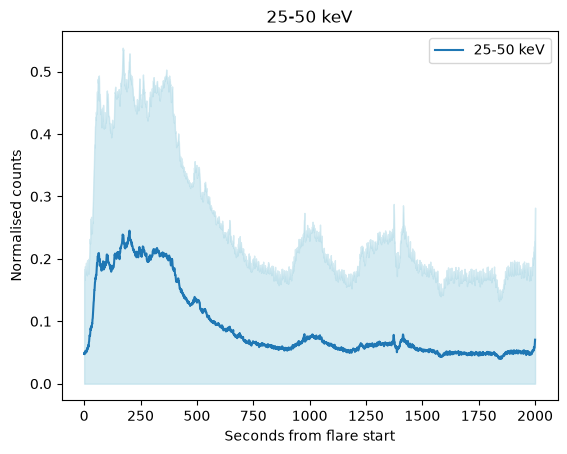

In [88]:
fig, ax = plt.subplots()

ax.plot(averaged_shape_flare_2550.index, averaged_shape_flare_2550['25.0 keV-50.0 keV'], label='25-50 keV')
plt.xlabel('Seconds from flare start')
plt.ylabel('Normalised counts')
#plt.legend()
plt.title('25-50 keV')
ax.legend()

ax.fill_between(averaged_shape_flare_2550.index, lowerlim_2550, upperlim_2550, color='lightblue', alpha=0.5)
    
#plt.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_7/200_top_counts_2550.png", bbox_inches='tight')

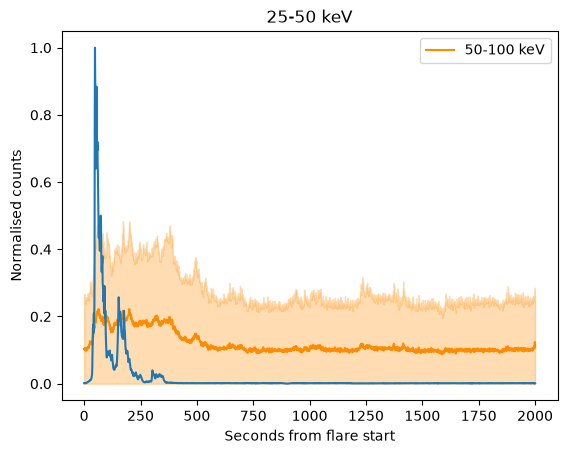

In [89]:
fig, ax = plt.subplots()

ax.plot(averaged_shape_flare_50100.index, averaged_shape_flare_50100['50.0 keV-100.0 keV'], color='darkorange', label='50-100 keV')
plt.xlabel('Seconds from flare start')
plt.ylabel('Normalised counts')
plt.legend()
plt.title('25-50 keV')
plt.plot(timeshifted_df_list[0].index, timeshifted_df_list[0]['50.0 keV-100.0 keV'])

ax.fill_between(averaged_shape_flare_50100.index, lowerlim_50100, upperlim_50100, color='darkorange', alpha=0.3)

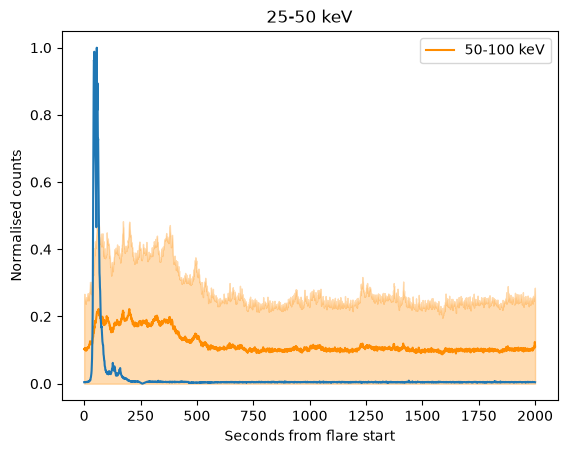

In [90]:
fig, ax = plt.subplots()

ax.plot(averaged_shape_flare_50100.index, averaged_shape_flare_50100['50.0 keV-100.0 keV'], color='darkorange', label='50-100 keV')
plt.xlabel('Seconds from flare start')
plt.ylabel('Normalised counts')
plt.legend()
plt.title('25-50 keV')
plt.plot(timeshifted_df_list[1].index, timeshifted_df_list[1]['50.0 keV-100.0 keV'])

ax.fill_between(averaged_shape_flare_50100.index, lowerlim_50100, upperlim_50100, color='darkorange', alpha=0.3)

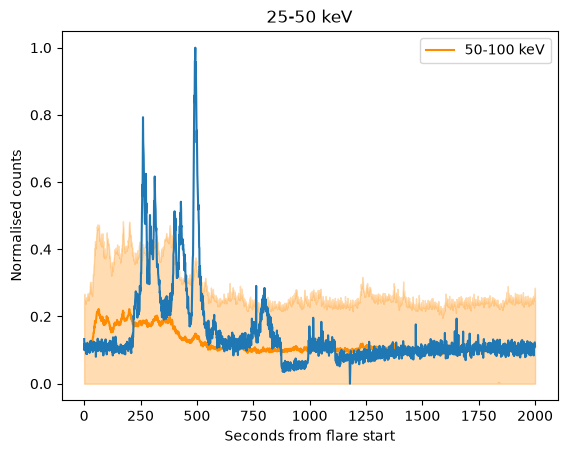

In [91]:
fig, ax = plt.subplots()

ax.plot(averaged_shape_flare_50100.index, averaged_shape_flare_50100['50.0 keV-100.0 keV'], color='darkorange', label='50-100 keV')
plt.xlabel('Seconds from flare start')
plt.ylabel('Normalised counts')
plt.legend()
plt.title('25-50 keV')
plt.plot(timeshifted_df_list[50].index, timeshifted_df_list[50]['50.0 keV-100.0 keV'])

ax.fill_between(averaged_shape_flare_50100.index, lowerlim_50100, upperlim_50100, color='darkorange', alpha=0.3)

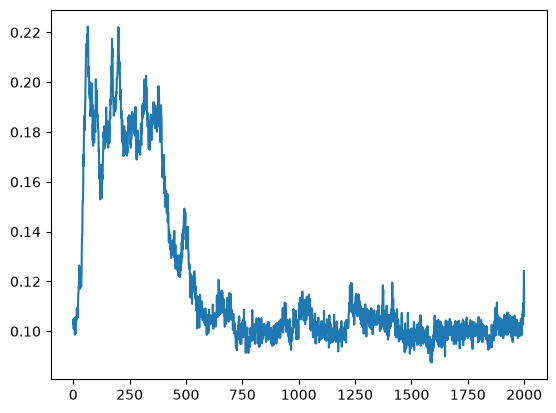

In [92]:
plt.plot(averaged_shape_flare_50100.index, averaged_shape_flare_50100['50.0 keV-100.0 keV'])

In [93]:
median_shape_flare_2550 = pd.DataFrame(concat_band1.median(axis=1), columns=['25.0 keV-50.0 keV'])
median_shape_flare_50100 = pd.DataFrame(concat_band2.median(axis=1), columns=['50.0 keV-100.0 keV'])

<Axes: >

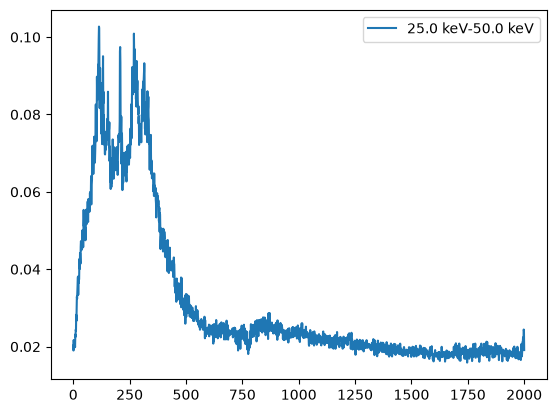

In [94]:
median_shape_flare_2550.plot()

In [95]:
resampled_df_list_peaks = []
i=0
for df in df_list_refined:
    #df = df.truncate(starts[i], starts[i]+dt.timedelta(seconds=max(durations)))
    resampled_df = df.resample('1s').mean()
    resampled_df['25.0 keV-50.0 keV'] = resampled_df['25.0 keV-50.0 keV'].interpolate('linear')
    resampled_df['50.0 keV-100.0 keV'] = resampled_df['50.0 keV-100.0 keV'].interpolate('linear')
    resampled_df_list_peaks.append(resampled_df)
    i+=1

normalised_df_list_peaks = []
for df in resampled_df_list_peaks:
    normalised_df = df.copy()
    normalised_df['25.0 keV-50.0 keV'] = (df['25.0 keV-50.0 keV']-np.min(df['25.0 keV-50.0 keV']))/(np.max(df['25.0 keV-50.0 keV'])-np.min(df['25.0 keV-50.0 keV']))
    normalised_df['50.0 keV-100.0 keV'] = (df['50.0 keV-100.0 keV']- np.min(df['50.0 keV-100.0 keV']))/(np.max(df['50.0 keV-100.0 keV'])-np.min(df['50.0 keV-100.0 keV']))
    normalised_df_list_peaks.append(normalised_df)

In [96]:
timeshifted_peaks_df_list = []
i=0
for df in normalised_df_list_peaks:
    timeshifted_df = df.copy()
    timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()
    
    #
    peak_time = df.index[df['25.0 keV-50.0 keV'] == np.max(df['25.0 keV-50.0 keV'])][0]
    peak_time = pd.to_datetime(t(peak_time)).round('1s')
    #

    total_peak_time = (peak_time - dt.datetime(2004, 11, 25)).total_seconds()
    
    timeshifted_df.index = timeshifted_df.index - total_peak_time
    timeshifted_df = timeshifted_df.truncate(-1000, 1000)
    timeshifted_peaks_df_list.append(timeshifted_df)
    i+=1

In [97]:
timeshifted_peaks_df_list_50100 = []
i=0
for df in normalised_df_list_peaks:
    timeshifted_df = df.copy()
    timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()
    
    #
    peak_time = df.index[df['50.0 keV-100.0 keV'] == np.max(df['50.0 keV-100.0 keV'])][0]
    peak_time = pd.to_datetime(t(peak_time)).round('1s')
    #

    total_peak_time = (peak_time - dt.datetime(2004, 11, 25)).total_seconds()
    
    timeshifted_df.index = timeshifted_df.index - total_peak_time
    timeshifted_df = timeshifted_df.truncate(-1000, 1000)
    timeshifted_peaks_df_list_50100.append(timeshifted_df)
    i+=1

In [98]:
ts_peaks_list = []
for df in timeshifted_peaks_df_list:
    new_index = pd.Index(np.arange(-1000, 1000, 1)) 
    df = df.set_index(df.index).reindex(new_index)
    ts_peaks_list.append(df)

In [99]:
ts_peaks_list_50100 = []
for df in timeshifted_peaks_df_list_50100:
    new_index = pd.Index(np.arange(-1000, 1000, 1)) 
    df = df.set_index(df.index).reindex(new_index)
    ts_peaks_list_50100.append(df)

In [100]:
concat_band1_peaks = pd.concat((df['25.0 keV-50.0 keV'] for df in ts_peaks_list), axis=1)
concat_band2_peaks = pd.concat((df['50.0 keV-100.0 keV'] for df in ts_peaks_list_50100), axis=1)
averaged_shape_flare_2550_peaks = pd.DataFrame(concat_band1_peaks.mean(axis=1), columns=['25.0 keV-50.0 keV'])
averaged_shape_flare_50100_peaks = pd.DataFrame(concat_band2_peaks.mean(axis=1), columns=['50.0 keV-100.0 keV'])

In [101]:
len(timeshifted_peaks_df_list[2]['25.0 keV-50.0 keV'])

2001

In [103]:
lengths=[]
for df in timeshifted_peaks_df_list:
    lengths.append(len(df['25.0 keV-50.0 keV']))
np.max(lengths)

np.int64(2001)

In [104]:
concat_band1_peaks

,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,...,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV,25.0 keV-50.0 keV
-1000,0.001934,0.003945,0.003945,0.004491,0.004189,0.004189,0.005556,0.005556,0.003091,0.006878,...,0.100656,0.017930,0.069690,0.062425,0.023358,0.017187,0.095708,0.095708,0.067146,0.069135
-999,0.001932,0.003878,0.003878,0.004324,0.004187,0.004187,0.005554,0.005554,0.003129,0.008135,...,0.089810,0.010466,0.070238,0.050272,0.023405,0.016791,0.096119,0.096119,0.070902,0.092335
-998,0.001934,0.003811,0.003811,0.004212,0.004186,0.004186,0.005552,0.005552,0.003166,0.007669,...,0.081675,0.014069,0.070786,0.061249,0.023452,0.016396,0.096531,0.096531,0.077005,0.078131
-997,0.001935,0.003810,0.003810,0.003403,0.004455,0.004455,0.005550,0.005550,0.003198,0.007158,...,0.083935,0.016128,0.071167,0.057329,0.023500,0.016000,0.096170,0.096170,0.079822,0.072449
-996,0.001937,0.003809,0.003809,0.004408,0.004206,0.004206,0.005548,0.005548,0.003229,0.006320,...,0.082127,0.018187,0.071548,0.059289,0.023547,0.015605,0.095809,0.095809,0.071841,0.073396
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.002888,0.003785,0.003785,0.002761,0.003827,0.003827,0.004374,0.004374,0.009115,0.020696,...,0.061790,0.011478,0.064945,0.122215,0.024515,0.015505,0.091425,0.091425,0.065737,0.069135
996,0.003480,0.003865,0.003865,0.002091,0.003048,0.003048,0.005756,0.005756,0.009518,0.020091,...,0.061790,0.011524,0.068945,0.121333,0.024447,0.015653,0.091453,0.091453,0.069493,0.077184
997,0.003409,0.003624,0.003624,0.002007,0.003914,0.003914,0.005814,0.005814,0.010070,0.021626,...,0.055915,0.013104,0.068500,0.123097,0.024379,0.015802,0.091481,0.091481,0.067615,0.070082
998,0.003101,0.003644,0.003644,0.002538,0.002904,0.002904,0.004580,0.004580,0.009815,0.020603,...,0.060886,0.014684,0.072500,0.123979,0.024310,0.015950,0.091508,0.091508,0.071371,0.057771


In [105]:
std_2550_peaks = concat_band1_peaks.std(axis=1)
std_50100_peaks = concat_band2_peaks.std(axis=1)

upperlim_2550_peaks = averaged_shape_flare_2550_peaks['25.0 keV-50.0 keV']+std_2550_peaks
lowerlim_2550_peaks = averaged_shape_flare_2550_peaks['25.0 keV-50.0 keV']-std_2550_peaks

for i in np.arange(-1000, 1000, 1):
    if lowerlim_2550_peaks.iloc[i]<0:
        lowerlim_2550_peaks.iloc[i] = 0

upperlim_50100_peaks = averaged_shape_flare_50100_peaks['50.0 keV-100.0 keV']+std_50100_peaks
lowerlim_50100_peaks = averaged_shape_flare_50100_peaks['50.0 keV-100.0 keV']-std_50100_peaks

for i in np.arange(-1000, 1000, 1):
    if lowerlim_50100_peaks.iloc[i]<0:
        lowerlim_50100_peaks.iloc[i] = 0

In [106]:
avg_peaks_filtered = pd.concat((averaged_shape_flare_2550_peaks, averaged_shape_flare_50100_peaks), axis=1)

# avg_peaks_filtered = avg_flare_peaks.copy()

# filtered_2550 = savgol_filter(avg_flare_peaks['25.0 keV-50.0 keV'], window_length = 55, polyorder=2)
# filtered_50100 = savgol_filter(avg_flare_peaks['50.0 keV-100.0 keV'], window_length = 55, polyorder=2)

# avg_peaks_filtered['25.0 keV-50.0 keV'] = filtered_2550
# avg_peaks_filtered['50.0 keV-100.0 keV'] = filtered_50100


In [107]:
half_max = 0.5*np.max(avg_peaks_filtered['25.0 keV-50.0 keV'])
half_max_loc = avg_peaks_filtered.index[avg_peaks_filtered['25.0 keV-50.0 keV']>= half_max][0]

over_half = np.where(avg_peaks_filtered['25.0 keV-50.0 keV']>half_max)
end_point = avg_peaks_filtered.index[over_half[0][-1]]

fwhm = (end_point-half_max_loc)
fwhm

np.int64(36)

In [108]:
half_max = 0.5*np.max(avg_peaks_filtered['50.0 keV-100.0 keV'])
half_max_loc = avg_peaks_filtered.index[avg_peaks_filtered['50.0 keV-100.0 keV']>= half_max][0]

over_half = np.where(avg_peaks_filtered['50.0 keV-100.0 keV']>half_max)
end_point = avg_peaks_filtered.index[over_half[0][-1]]

fwhm = (end_point-half_max_loc)
fwhm

np.int64(20)

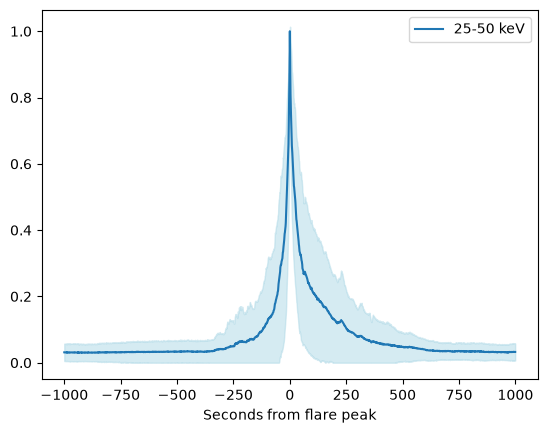

In [109]:
fig, ax = plt.subplots()

ax.plot(averaged_shape_flare_2550_peaks.index, averaged_shape_flare_2550_peaks['25.0 keV-50.0 keV'], label = '25-50 keV')
ax.fill_between(averaged_shape_flare_2550_peaks.index, lowerlim_2550_peaks, upperlim_2550_peaks, color='lightblue', alpha=0.5)
ax.set_xlabel('Seconds from flare peak')
ax.legend()
fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_8/figs_for_presentation/normalised_peak_2550.png", bbox_inches='tight')

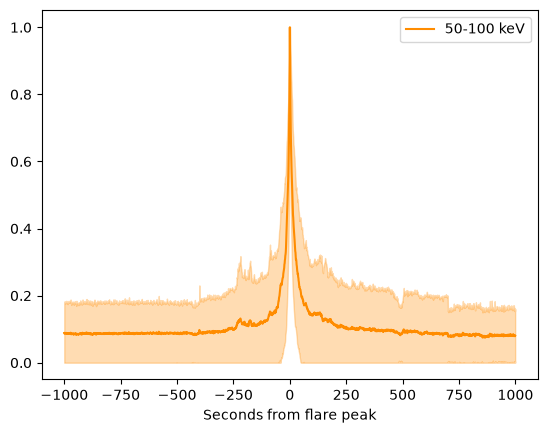

In [110]:
fig, ax = plt.subplots()

ax.plot(averaged_shape_flare_50100_peaks.index, averaged_shape_flare_50100_peaks['50.0 keV-100.0 keV'], color='darkorange', label='50-100 keV')
ax.fill_between(averaged_shape_flare_50100_peaks.index, lowerlim_50100_peaks, upperlim_50100_peaks, color='darkorange', alpha=0.3)
ax.set_xlabel('Seconds from flare peak')
ax.legend()
fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_8/figs_for_presentation/normalised_peak_50100.png", bbox_inches='tight')

In [111]:
len(df_list_refined)

98

In [112]:
# concat_band1 = pd.concat((df['25.0 keV-50.0 keV'] for df in timeshifted_df_list_full), axis=1)
# concat_band2 = pd.concat((df['50.0 keV-100.0 keV'] for df in timeshifted_df_list_full), axis=1)
# averaged_shape_flare_2550_full = pd.DataFrame(concat_band1.mean(axis=1), columns=['25.0 keV-50.0 keV'])
# averaged_shape_flare_50100_full = pd.DataFrame(concat_band2.mean(axis=1), columns=['50.0 keV-100.0 keV'])

In [113]:
#plt.plot(averaged_shape_flare_2550_full.index, averaged_shape_flare_2550_full['25.0 keV-50.0 keV'])

In [114]:
i=0
track=0
for i in range(len(df_list)):
    if i not in no_file:
        df = df_list[i]
        fig, ax = plt.subplots()
        ax.set_ylabel('ct/(keV s)')
        ax.set_title(f"{parse_time(flarelist['start_UTC'].iloc[i]).datetime.year}-{parse_time(flarelist['start_UTC'].iloc[i]).datetime.month}-{parse_time(flarelist['start_UTC'].iloc[i]).datetime.day} {parse_time(flarelist['start_UTC'].iloc[i]).datetime.hour}:{parse_time(flarelist['start_UTC'].iloc[i]).datetime.minute}")
        ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))
        
        ax.plot(t(df.index), df['25.0 keV-50.0 keV'])
        ax.plot(t(df.index), df['50.0 keV-100.0 keV'])
    
        plt.axvline(t(flarelist['start_UTC'].iloc[i]), 0, 1, linestyle='dashed', color='yellow')
        plt.axvline(t(flarelist['end_UTC'].iloc[i]), 0, 1, linestyle='dashed', color='yellow')
        
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper right', fontsize='small')
        fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_7/test1/flare"+str(i)+".png", bbox_inches='tight')
        track+=1

plt.close('all')

C:\Users\dearb\AppData\Local\Temp\ipykernel_26496\661505284.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [115]:
i=0
track=0
for i in range(len(df_list)):
    if i not in checklist2:
        df = df_list_refined[track]
        fig, ax = plt.subplots()
        ax.set_ylabel('ct/(keV s)')
        ax.set_title(f"{parse_time(flarelist['start_UTC'].iloc[i]).datetime.year}-{parse_time(flarelist['start_UTC'].iloc[i]).datetime.month}-{parse_time(flarelist['start_UTC'].iloc[i]).datetime.day} {parse_time(flarelist['start_UTC'].iloc[i]).datetime.hour}:{parse_time(flarelist['start_UTC'].iloc[i]).datetime.minute}")
        ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))
    
        start = t(times_25_50[0][track])
        end = t(times_25_50[1][track])
        
        df = df.truncate(start - dt.timedelta(minutes=30), end + dt.timedelta(minutes=30))
        
        ax.plot(t(df.index), df['25.0 keV-50.0 keV'])
        ax.plot(t(df.index), df['50.0 keV-100.0 keV'])
    
        plt.axvline(start, 0, 1, linestyle='dashed', color='palevioletred')
        plt.axvline(end, 0, 1, linestyle='dashed', color='palevioletred')
        
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper right', fontsize='small')
        fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_7/2550_counts_durations/flare"+str(i)+".png", bbox_inches='tight')
        track+=1

plt.close('all')

C:\Users\dearb\AppData\Local\Temp\ipykernel_26496\1690103985.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


- Duration normalised:

In [116]:
timeshifted_df_list_durations = []
i=0
for df in normalised_df_list:
    timeshifted_df = df.copy()
    timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()
    
    #
    start = pd.to_datetime(t(starts[i])).round('1s')
    end = pd.to_datetime(t(ends[i])).round('1s')
    #
    
    # total_start = (estimated_starts_x[i] - dt.datetime(2004, 11, 25)).total_seconds()
    # total_end = (estimated_ends_x[i] - dt.datetime(2004, 11, 25)).total_seconds()

    total_start = (start - dt.datetime(2004, 11, 25)).total_seconds()
    total_end = (end - dt.datetime(2004, 11, 25)).total_seconds()

    
    timeshifted_df.index = timeshifted_df.index - total_start
    timeshifted_df = timeshifted_df.truncate(0, durations[i])
    timeshifted_df.index = timeshifted_df.index/durations[i]
    timeshifted_df_list_durations.append(timeshifted_df)
    i+=1

In [117]:

resampled_ind = np.linspace(0, 1, 1000)

resampled_duration_norm = []
for df in timeshifted_df_list_durations:
    resampled_df = df.reindex(df.index.union(resampled_ind)).interpolate('linear').loc[resampled_ind]
    resampled_duration_norm.append(resampled_df)

In [118]:
concat_band1_durations = pd.concat((df['25.0 keV-50.0 keV'] for df in resampled_duration_norm), axis=1)
averaged_shape_flare_2550_durations = pd.DataFrame(concat_band1_durations.mean(axis=1), columns=['25.0 keV-50.0 keV'])

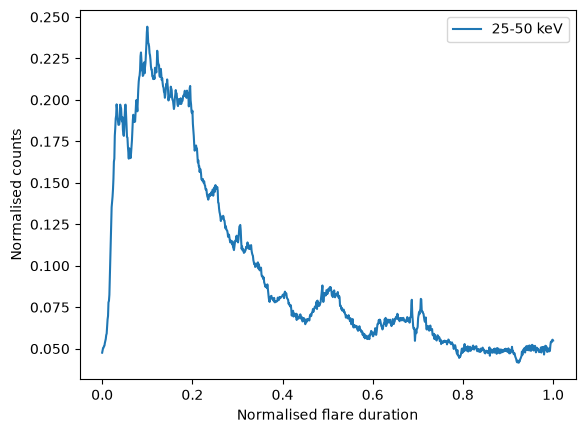

In [119]:
plt.plot(averaged_shape_flare_2550_durations.index, averaged_shape_flare_2550_durations['25.0 keV-50.0 keV'], label='25-50 keV')
plt.xlabel('Normalised flare duration')
plt.ylabel('Normalised counts')
plt.legend()
#plt.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_7/duration_normalised_2550.png", bbox_inches='tight')

In [120]:
peak_ratios = []
durations_for_plot = []
i=0
for df in resampled_df_list:
    df = df.truncate(starts[i], ends[i])
    peak_2550 = np.max(df['25.0 keV-50.0 keV'])
    peak_50100 = np.max(df['50.0 keV-100.0 keV'])
    peak_ratio = peak_50100/peak_2550
    if peak_ratio<1:
        peak_ratios.append(peak_ratio)
        if durations[i]<=3600:
            durations_for_plot.append(durations[i])
        else:
            durations_for_plot.append(3600)
    i+=1




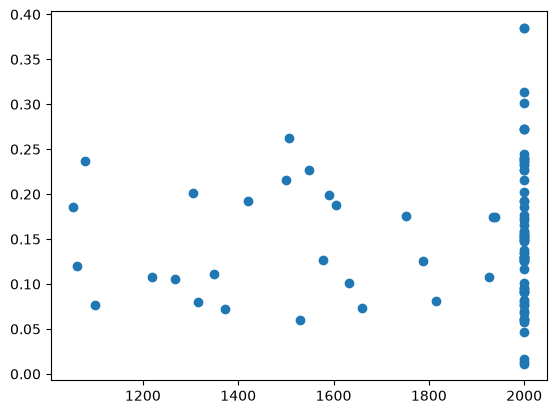

In [121]:
plt.scatter(durations_for_plot, peak_ratios)

In [122]:
len(flarelist.index)

200

In [123]:
df=df_list_extrafiltered[0]
df.index[np.where(df['25.0 keV-50.0 keV']==np.max(df['25.0 keV-50.0 keV']))[0][0]]

Timestamp('2024-05-14 16:45:03.071000')

In [124]:
threshold_starts = []
threshold_ends = []
durations = []
i=0
for df in df_list_extrafiltered:
    start = parse_time(flarelist['start_UTC'].loc[indices_refined[i]]).datetime - dt.timedelta(minutes=10)
    end = parse_time(flarelist['end_UTC'].loc[indices_refined[i]]).datetime  + dt.timedelta(minutes=10)

    df.index = parse_time(df.index).datetime 
    df = df.truncate(start, end)
        
    r = flarelist['solo_position_AU_distance'].loc[indices_refined[i]]

    peak_loc = df.index[np.where(df['25.0 keV-50.0 keV']==np.max(df['25.0 keV-50.0 keV']))[0][0]]

    flare = df[df['25.0 keV-50.0 keV']>10/r**2]
    if not flare.empty:
        tstart = flare.index[0]
        if not df[(df['25.0 keV-50.0 keV']<10/r**2) & (df.index>peak_loc)].empty:
            tend = df[(df['25.0 keV-50.0 keV']<10/r**2) & (df.index>peak_loc)].index[0]
            duration = tend - tstart
            duration = duration.total_seconds()
        else:
            tend=np.nan
            tstart=np.nan
            duration = np.nan
    else:
        tstart = np.nan
        tend=np.nan
        duration = np.nan

    threshold_starts.append(tstart)
    threshold_ends.append(tend)
    durations.append(duration)

    i+=1

In [125]:
ds = []
for dur in durations:
    if pd.notna(dur):
        ds.append(dur)

In [126]:
np.max(ds)

np.float64(1117.0)

In [127]:
timeshifted_df_list_thresholds = []
i=0
for df in normalised_df_list:
    if pd.notna(threshold_starts[i]):
        timeshifted_df = df.copy()
        timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()
        
        #
        start_time = threshold_starts[i]
        start_time = pd.to_datetime(t(start_time)).round('1s')

        end_time = threshold_ends[i]
        end_time = pd.to_datetime(t(end_time)).round('1s')
        #
    
        total_start_time = (start_time - dt.datetime(2004, 11, 25)).total_seconds()
        
        timeshifted_df.index = timeshifted_df.index - total_start_time
        timeshifted_df = timeshifted_df.truncate(0, np.max(ds))
        timeshifted_df_list_thresholds.append(timeshifted_df)
    i+=1

In [128]:
concat_band1_th = pd.concat((df['25.0 keV-50.0 keV'] for df in timeshifted_df_list_thresholds), axis=1)
concat_band2_th = pd.concat((df['50.0 keV-100.0 keV'] for df in timeshifted_df_list_thresholds), axis=1)
averaged_shape_flare_2550_th = pd.DataFrame(concat_band1_th.mean(axis=1), columns=['25.0 keV-50.0 keV'])
averaged_shape_flare_50100_th = pd.DataFrame(concat_band2_th.mean(axis=1), columns=['50.0 keV-100.0 keV'])

In [129]:
std_2550_mean_th = concat_band1_th.std(axis=1)
std_50100_mean_th = concat_band2_th.std(axis=1)

upperlim_2550_th = averaged_shape_flare_2550_th['25.0 keV-50.0 keV']+std_2550_mean_th
lowerlim_2550_th = averaged_shape_flare_2550_th['25.0 keV-50.0 keV']-std_2550_mean_th

for i in np.arange(0, len(upperlim_2550_th), 1):
    if lowerlim_2550_th.iloc[i]<0:
        lowerlim_2550_th.iloc[i] = 0

upperlim_50100_th = averaged_shape_flare_50100_th['50.0 keV-100.0 keV']+std_50100_mean_th
lowerlim_50100_th = averaged_shape_flare_50100_th['50.0 keV-100.0 keV']-std_2550_mean_th

for i in np.arange(0, len(upperlim_2550_th), 1):
    if lowerlim_50100_th.iloc[i]<0:
        lowerlim_50100_th.iloc[i] = 0

In [130]:
n = concat_band1.notna().sum(axis=1)
print(concat_band1.shape, n.max(), n.median())

(2001, 98) 98 98.0


In [131]:
np.where(n<50)

(array([2000]),)

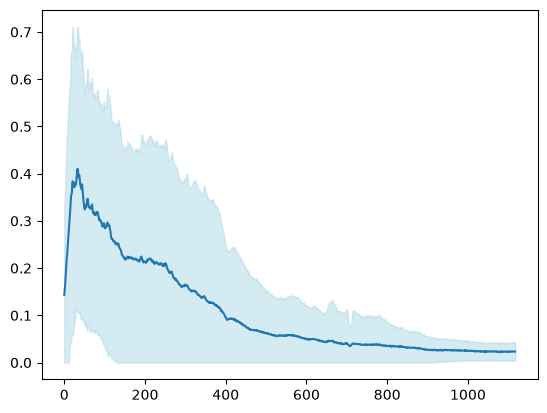

In [132]:
fig, ax = plt.subplots()

ax.plot(averaged_shape_flare_2550_th.index, averaged_shape_flare_2550_th['25.0 keV-50.0 keV'])
ax.fill_between(averaged_shape_flare_2550_th.index, lowerlim_2550_th, upperlim_2550_th, color = 'lightblue', alpha=0.5)

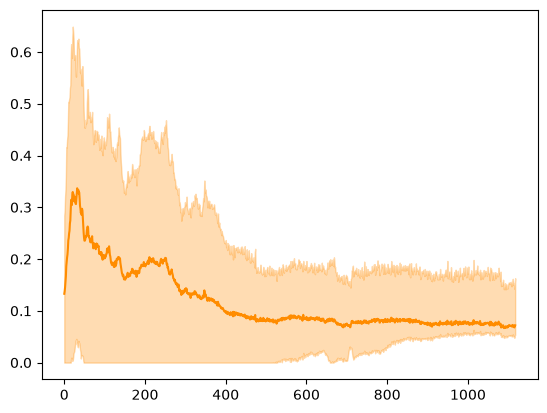

In [133]:
fig, ax = plt.subplots()

ax.plot(averaged_shape_flare_50100_th.index, averaged_shape_flare_50100_th['50.0 keV-100.0 keV'], color='darkorange')
ax.fill_between(averaged_shape_flare_50100_th.index, lowerlim_50100_th, upperlim_50100_th, color = 'darkorange', alpha=0.3)

In [134]:
fwhm_list = []
i=0
for df in df_list_refined:
    df = df.truncate(t(starts[i])-dt.timedelta(minutes=5), t(ends[i])+dt.timedelta(minutes=5))

    half_max = 0.5*np.max(df['25.0 keV-50.0 keV'])
    half_max_loc = df.index[df['25.0 keV-50.0 keV']>= half_max][0]
    
    over_half = np.where(df['25.0 keV-50.0 keV']>half_max)
    end_point = df.index[over_half[0][-1]]
    
    fwhm = (end_point-half_max_loc)
    fwhm = fwhm.total_seconds()
    fwhm_list.append(fwhm)
    i+=1

In [135]:
np.mean(fwhm_list)

np.float64(96.95561224489795)

In [136]:
fwhm_list_50100 = []
i=0
for df in df_list_refined:
    df = df.truncate(t(starts[i])-dt.timedelta(minutes=5), t(ends[i])+dt.timedelta(minutes=5))

    if np.max(df['50.0 keV-100.0 keV'])<3:
        fwhm_list_50100.append(np.nan)
    else:
        half_max = 0.5*np.max(df['50.0 keV-100.0 keV'])
        half_max_loc = df.index[df['50.0 keV-100.0 keV']>= half_max][0]
        
        over_half = np.where(df['50.0 keV-100.0 keV']>half_max)
        end_point = df.index[over_half[0][-1]]
        
        fwhm = (end_point-half_max_loc)
        fwhm = fwhm.total_seconds()
        if fwhm>fwhm_list[i]:
            fwhm = fwhm_list[i]
        fwhm_list_50100.append(fwhm)
    i+=1

In [137]:
np.nanmean(fwhm_list_50100)

np.float64(66.86958762886599)

In [186]:
df_list_filtered = []
for df in resampled_df_list:
    df_filtered = df.copy()
    
    filtered_2550 = savgol_filter(df['25.0 keV-50.0 keV'], window_length = 25, polyorder=2)
    filtered_50100 = savgol_filter(df['50.0 keV-100.0 keV'], window_length = 25, polyorder=2)

    df_filtered['25.0 keV-50.0 keV'] = filtered_2550
    df_filtered['50.0 keV-100.0 keV'] = filtered_50100

    df_list_filtered.append(df_filtered)

In [139]:
i=0
for df in df_list_filtered:
    fig, ax = plt.subplots()
    df = df.truncate(starts[i], ends[i])
    ax.plot(df.index, df['25.0 keV-50.0 keV'])
    #plt.axvline(df.index[firstpeaks[i]], 0, 1, linestyle='dashed', color='red')
    fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_9/filtering_testing/flare"+str(i)+".png", bbox_inches='tight')
    i+=1
plt.close('all')

C:\Users\dearb\AppData\Local\Temp\ipykernel_26496\3575634000.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [140]:
i=0
for df in df_list_refined:
    fig, ax = plt.subplots()
    df = df.truncate(starts[i], ends[i])
    ax.plot(df.index, df['25.0 keV-50.0 keV'])
    #plt.axvline(df.index[firstpeaks[i]], 0, 1, linestyle='dashed', color='red')
    fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_9/filtering_compare/flare"+str(i)+".png", bbox_inches='tight')
    i+=1
plt.close('all')

C:\Users\dearb\AppData\Local\Temp\ipykernel_26496\3969503559.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [222]:
i=0
firstpeaks = []
for df in df_list_filtered:
    fig, ax = plt.subplots()
    df = df.truncate(starts[i], ends[i])
    peak_counts=np.max(df['25.0 keV-50.0 keV'])
    peaks, properties = find_peaks(df['25.0 keV-50.0 keV'], prominence=0.05*peak_counts) #distance=15,
    firstpeaks.append(peaks[0])
    
    # df = df_list_refined[i]
    # df = df.truncate(starts[i], ends[i])
    ax.plot(df. index, df['25.0 keV-50.0 keV'])
    ax.scatter(df.index[peaks], df['25.0 keV-50.0 keV'].iloc[peaks], color='black', marker='*')
    fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_9/peak_testing/flare"+str(i)+".png", bbox_inches='tight')
    i+=1

plt.close('all')

C:\Users\dearb\AppData\Local\Temp\ipykernel_26496\901306061.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [223]:
timeshifted_df_list_firstpeak = []
i=0
for df in normalised_df_list_peaks:
    timeshifted_df = df.copy()
    timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()
    
    #
    df = df.truncate(starts[i], ends[i])
    peak_time = df.index[firstpeaks[i]]
    peak_time = pd.to_datetime(t(peak_time)).round('1s')
    #

    total_peak_time = (peak_time - dt.datetime(2004, 11, 25)).total_seconds()
    
    timeshifted_df.index = timeshifted_df.index - total_peak_time
    timeshifted_df = timeshifted_df.truncate(-200, 1800)
    timeshifted_df_list_firstpeak.append(timeshifted_df)
    i+=1

firstpeak_list = []
for df in timeshifted_df_list_firstpeak:
    new_index = pd.Index(np.arange(-200, 1800, 1)) 
    df = df.set_index(df.index).reindex(new_index)
    firstpeak_list.append(df)

In [191]:
i=0
for df in firstpeak_list:
    fig, ax = plt.subplots()
    #df = df.truncate(starts[i], ends[i])
    ax.plot(df.index, df['25.0 keV-50.0 keV'])
    #plt.axvline(df.index[firstpeaks[i]], 0, 1, linestyle='dashed', color='red')
    fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_9/flare"+str(i)+".png", bbox_inches='tight')
    i+=1
plt.close('all')

C:\Users\dearb\AppData\Local\Temp\ipykernel_26496\192223436.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [192]:
i=0
for df in timeshifted_df_list_firstpeak:
    fig, ax = plt.subplots()
    ax.plot(df.index, df['25.0 keV-50.0 keV'])
    fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_9/flare"+str(i)+".png", bbox_inches='tight')
    i+=1
plt.close('all')

C:\Users\dearb\AppData\Local\Temp\ipykernel_26496\1294654368.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [224]:
concat_band1_firstpeak = pd.concat((df['25.0 keV-50.0 keV'] for df in firstpeak_list), axis=1)
#concat_band2_firstpeak = pd.concat((df['50.0 keV-100.0 keV'] for df in ts_peaks_list_50100), axis=1)
averaged_shape_flare_2550_firstpeak = pd.DataFrame(concat_band1_firstpeak.mean(axis=1), columns=['25.0 keV-50.0 keV'])
#averaged_shape_flare_50100_peaks = pd.DataFrame(concat_band2_peaks.mean(axis=1), columns=['50.0 keV-100.0 keV'])

In [225]:
n = concat_band1_firstpeak.notna().sum(axis=1)
print(concat_band1_firstpeak.shape, n.max(), n.median())

(2000, 98) 98 98.0


In [226]:
np.where(n<50)

(array([], dtype=int64),)

In [227]:
std_2550_mean_firstpeak = concat_band1_firstpeak.std(axis=1)
# std_50100_mean_fp = concat_band2_firstpeak.std(axis=1)

upperlim_2550_firstpeak = averaged_shape_flare_2550_firstpeak['25.0 keV-50.0 keV']+std_2550_mean_firstpeak
lowerlim_2550_firstpeak = averaged_shape_flare_2550_firstpeak['25.0 keV-50.0 keV']-std_2550_mean_firstpeak

for i in np.arange(0, len(upperlim_2550_firstpeak), 1):
    if lowerlim_2550_firstpeak.iloc[i]<0:
        lowerlim_2550_firstpeak.iloc[i] = 0

# upperlim_50100_firstpeak = averaged_shape_flare_50100_firstpeak['50.0 keV-100.0 keV']+std_50100_mean_th
# lowerlim_50100_firstpeak = averaged_shape_flare_50100_firstpeak['50.0 keV-100.0 keV']-std_2550_mean_th

# for i in np.arange(0, len(upperlim_2550_th), 1):
#     if lowerlim_50100_th.iloc[i]<0:
#         lowerlim_50100_th.iloc[i] = 0

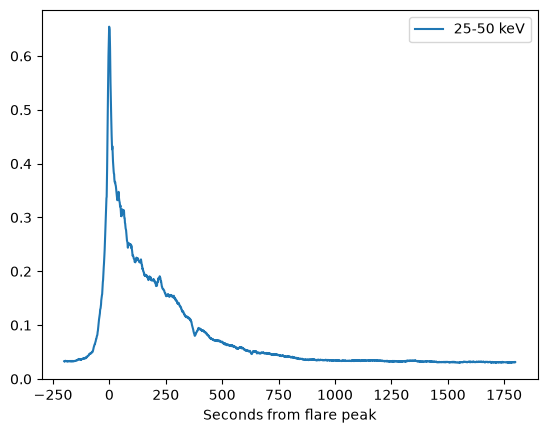

In [228]:
fig, ax = plt.subplots()

ax.plot(averaged_shape_flare_2550_firstpeak.index, averaged_shape_flare_2550_firstpeak['25.0 keV-50.0 keV'], label = '25-50 keV')
#ax.fill_between(averaged_shape_flare_2550_firstpeak.index, lowerlim_2550_firstpeak, upperlim_2550_firstpeak, color='lightblue', alpha=0.5)
ax.set_xlabel('Seconds from flare peak')
ax.legend()

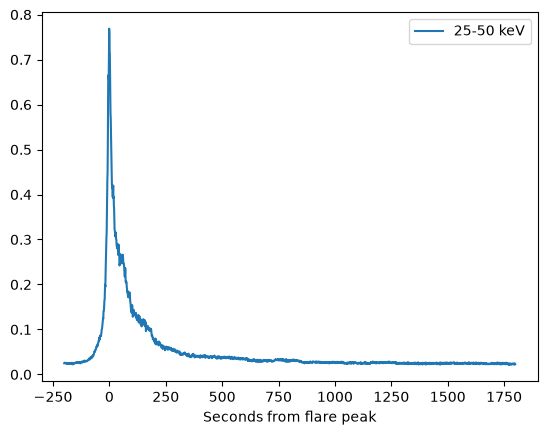

In [229]:
median_flare_2550_firstpeak = pd.DataFrame(concat_band1_firstpeak.median(axis=1), columns=['25.0 keV-50.0 keV'])

fig, ax = plt.subplots()

ax.plot(median_flare_2550_firstpeak.index, median_flare_2550_firstpeak['25.0 keV-50.0 keV'], label = '25-50 keV')
#ax.fill_between(averaged_shape_flare_2550_firstpeak.index, lowerlim_2550_firstpeak, upperlim_2550_firstpeak, color='lightblue', alpha=0.5)
ax.set_xlabel('Seconds from flare peak')
ax.legend()

(-300.0, 1800.0)

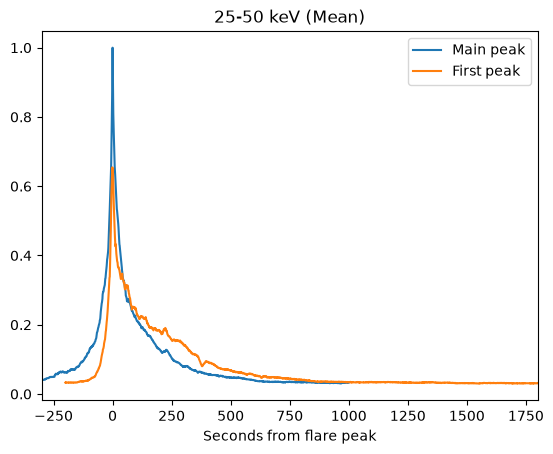

In [230]:
fig, ax = plt.subplots()

ax.plot(averaged_shape_flare_2550_peaks.index, averaged_shape_flare_2550_peaks['25.0 keV-50.0 keV'], label = 'Main peak')
ax.plot(averaged_shape_flare_2550_firstpeak.index, averaged_shape_flare_2550_firstpeak['25.0 keV-50.0 keV'], label = 'First peak')
#ax.fill_between(averaged_shape_flare_2550_peaks.index, lowerlim_2550_peaks, upperlim_2550_peaks, color='lightblue', alpha=0.5)
ax.set_xlabel('Seconds from flare peak')
ax.legend()
ax.set_title('25-50 keV (Mean)')
ax.set_xlim(-300, 1800)

(-300.0, 1800.0)

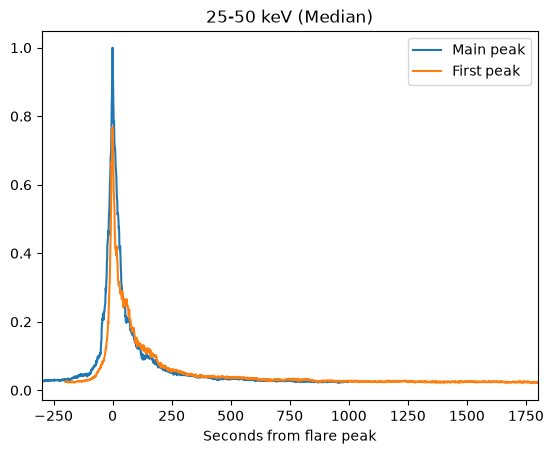

In [231]:
median_flare_2550_peaks = pd.DataFrame(concat_band1_peaks.median(axis=1), columns=['25.0 keV-50.0 keV'])

fig, ax = plt.subplots()

ax.plot(median_flare_2550_peaks.index, median_flare_2550_peaks['25.0 keV-50.0 keV'], label = 'Main peak')
ax.plot(median_flare_2550_firstpeak.index, median_flare_2550_firstpeak['25.0 keV-50.0 keV'], label = 'First peak')
#ax.fill_between(averaged_shape_flare_2550_peaks.index, lowerlim_2550_peaks, upperlim_2550_peaks, color='lightblue', alpha=0.5)
ax.set_xlabel('Seconds from flare peak')
ax.legend()
ax.set_title('25-50 keV (Median)')
ax.set_xlim(-300, 1800)

In [232]:
half_max = 0.5*np.max(averaged_shape_flare_2550_peaks['25.0 keV-50.0 keV'])
half_max_loc = averaged_shape_flare_2550_peaks.index[averaged_shape_flare_2550_peaks['25.0 keV-50.0 keV']>= half_max][0]

over_half = np.where(averaged_shape_flare_2550_peaks['25.0 keV-50.0 keV']>half_max)
end_point = averaged_shape_flare_2550_peaks.index[over_half[0][-1]]

fwhm = (end_point-half_max_loc)
fwhm

np.int64(36)

In [200]:
test_filt = []
for df in df_list_filtered:
    test_filt.append(df.index[0])

test_norm = []
for df in normalised_df_list_peaks:
    test_norm.append(df.index[0])